In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("DATA/who_tb_data.csv")

df.info()

df.columns = ["Country","WHO_region","Country_code","Iso2","Iso3","Year","Case_Detection_Rate","New_Case_100k","Case_Fatality_Ratio","e_inc_100k",
    "e_inc_num","e_mort_100k","e_mort_exc_tbhiv_100k","e_mort_exc_tbhiv_num","e_mort_num","e_mort_tbhiv_100k","e_mort_tbhiv_num","e_pop_num"]

#------------------------------------
ulkeler = ["Austria","Bahamas","Bahrain","Cabo Verde","Central African Republic","Chad","Comoros","Djibouti","Equatorial Guinea","French Polynesia",
    "Gabon","Guinea-Bissau","Italy","Latvia","Liberia","Libya","Madagascar","Mauritania","Micronesia (Federated States of)","New Caledonia",
    "occupied Palestinian territory","Palau","Qatar","Samoa","Seychelles","Suriname","Timor-Leste","Togo","Tuvalu","Ukraine"]

sutunlar = ["Case_Detection_Rate", "New_Case_100k"]
df[sutunlar] = df[sutunlar].replace("NA", np.nan)
df[sutunlar] = df[sutunlar].apply(pd.to_numeric)

for idx in df[df["Country"].isin(ulkeler)].index:
    for col in sutunlar:

        # Eğer değer eksikse
        if pd.isna(df.loc[idx, col]):

            prev_value = df.loc[idx - 1, col] if idx - 1 in df.index else np.nan
            next_value = df.loc[idx + 1, col] if idx + 1 in df.index else np.nan

            # Ortalama al
            mean_value = np.nanmean([prev_value, next_value])

            df.loc[idx, col] = mean_value

#------------------------------------

silinecek_ulkeler = ["American Samoa", "Andorra", "Anguilla", "Antigua and Barbuda", "Aruba", "Barbados", "Bermuda", "British Virgin Islands", 
                     "Cayman Islands", "Cook Islands", "Curaçao", "Democratic People's Republic of Korea", "Dominica", "Greenland", "Grenada", 
                     "Monaco", "Montserrat", "Nauru", "Niue", "Saint Kitts and Nevis", "San Marino", "Seychelles", "Sint Maarten (Dutch part)", 
                     "Tokelau", "Turks and Caicos Islands", "Wallis and Futuna"]

df_filtered = df[~df["Country"].isin(silinecek_ulkeler)].copy()

df_filtered["e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k"] = df_filtered["e_mort_tbhiv_100k"] / df_filtered["e_mort_exc_tbhiv_100k"]

df_filtered.to_csv("veri_temiz.csv", index=False)

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5117 entries, 0 to 5116
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                5117 non-null   object 
 1   g_whoregion            5117 non-null   object 
 2   iso_numeric            5117 non-null   int64  
 3   iso2                   5117 non-null   object 
 4   iso3                   5117 non-null   object 
 5   year                   5117 non-null   int64  
 6   c_cdr                  4838 non-null   float64
 7   c_newinc_100k          4946 non-null   float64
 8   cfr                    4989 non-null   float64
 9   e_inc_100k             5117 non-null   float64
 10  e_inc_num              5117 non-null   int64  
 11  e_mort_100k            5093 non-null   float64
 12  e_mort_exc_tbhiv_100k  5093 non-null   float64
 13  e_mort_exc_tbhiv_num   5093 non-null   float64
 14  e_mort_num             5093 non-null   float64
 15  e_mo

In [36]:
df = pd.read_csv("veri_temiz.csv")
df.info()

cols = ["Case_Fatality_Ratio","Case_Detection_Rate","e_inc_100k","e_inc_num","e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k"]

summary = pd.DataFrame({
    "Count": df[cols].count(),
    "Mean": df[cols].mean(),
    "Std": df[cols].std(),
    "Min": df[cols].min(),
    "Median": df[cols].median(),
    "Max": df[cols].max(),
    "Skewness": df[cols].skew()
})

summary = summary.round(2)
summary.style.background_gradient(cmap="Blues")
print(summary)
summary.to_excel("summary_statistics.xlsx")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country                                  4513 non-null   object 
 1   WHO_region                               4513 non-null   object 
 2   Country_code                             4513 non-null   int64  
 3   Iso2                                     4513 non-null   object 
 4   Iso3                                     4513 non-null   object 
 5   Year                                     4513 non-null   int64  
 6   Case_Detection_Rate                      4513 non-null   float64
 7   New_Case_100k                            4513 non-null   float64
 8   Case_Fatality_Ratio                      4513 non-null   float64
 9   e_inc_100k                               4513 non-null   float64
 10  e_inc_num                                4513 no

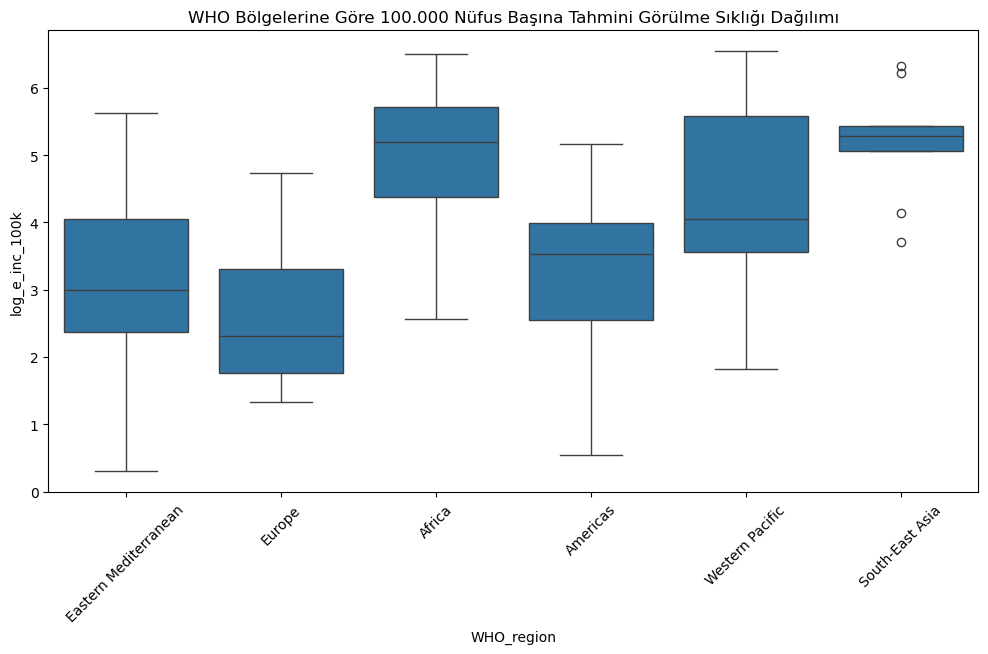


ANOVA Sonuçları:
                     sum_sq     df          F        PR(>F)
C(WHO_region)  1.267718e+06    5.0  16.604528  1.653474e-13
Residual       2.794327e+06  183.0        NaN           NaN


                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
        group1                group2         meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------------------------
               Africa              Americas -166.8663    0.0 -249.5681  -84.1645   True
               Africa Eastern Mediterranean  -147.157 0.0001 -239.4128  -54.9012   True
               Africa                Europe -185.7937    0.0 -258.5048 -113.0825   True
               Africa       South-East Asia   27.3043 0.9905 -102.4167  157.0254  False
               Africa       Western Pacific  -41.4021 0.7014 -124.1039   41.2997  False
             Americas Eastern Mediterranean   19.7093 0.9927  -79.5052  118.9238  False
        

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv("veri_temiz.csv")
df_2023 = df[df["Year"] == 2023].copy()


df_2023["log_e_inc_100k"] = np.log1p(df_2023["e_inc_100k"])
plt.figure(figsize=(12,6))

sns.boxplot(
    x="WHO_region",
    y="log_e_inc_100k",
    data=df_2023
)
plt.xticks(rotation=45)
plt.title("WHO Bölgelerine Göre 100.000 Nüfus Başına Tahmini Görülme Sıklığı Dağılımı")
plt.show()


model = ols('e_inc_100k ~ C(WHO_region)', data=df_2023).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA Sonuçları:")
print(anova_table)
print("\n")


import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("veri_temiz.csv")

tukey = pairwise_tukeyhsd(
    endog=df_2023["e_inc_100k"],
    groups=df_2023["WHO_region"],
    alpha=0.05
)
print(tukey)

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("veri_temiz.csv")

numeric_cols = ["Year","Case_Detection_Rate","Case_Fatality_Ratio","e_inc_100k","e_inc_num","e_pop_num"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_2023 = df[df["Year"] == 2023].copy()

def weighted_mean(values, weights):

    mask = (~values.isna()) & (~weights.isna())

    values = values[mask]
    weights = weights[mask]

    if weights.sum() == 0:
        return np.nan

    return np.average(values, weights=weights)

region_summary = (
    df_2023
    .groupby("WHO_region")
    .apply(lambda x: pd.Series({

       # e_inc_100k için nüfus ağırlıklı ortalama
        "Ortalama_Gorulme_100k":
            weighted_mean(
                x["e_inc_100k"],
                x["e_pop_num"]
            ),

        # Vaka ölüm oranı
        # ağırlık = toplam TB vakası
        "Vaka_Olum_Orani":
            weighted_mean(
                x["Case_Fatality_Ratio"],
                x["e_inc_num"]
            ),

        # Vaka tespit oranı
        # ağırlık = toplam TB vakası
        "Vaka_Tespit_Orani":
            weighted_mean(
                x["Case_Detection_Rate"],
                x["e_inc_num"]
            )
        }),
        include_groups=False
    )
    .round(2)
)

print(region_summary)
region_summary.to_excel(
    "2023_bolge_bazli_tb_analizi.xlsx"
)

                       Ortalama_Gorulme_100k  Vaka_Olum_Orani  \
WHO_region                                                      
Africa                                206.14             0.17   
Americas                               32.97             0.11   
Eastern Mediterranean                 115.45             0.09   
Europe                                 24.03             0.11   
South-East Asia                       205.97             0.13   
Western Pacific                       133.64             0.08   

                       Vaka_Tespit_Orani  
WHO_region                                
Africa                             73.98  
Americas                           77.87  
Eastern Mediterranean              68.24  
Europe                             76.66  
South-East Asia                    79.96  
Western Pacific                    74.11  


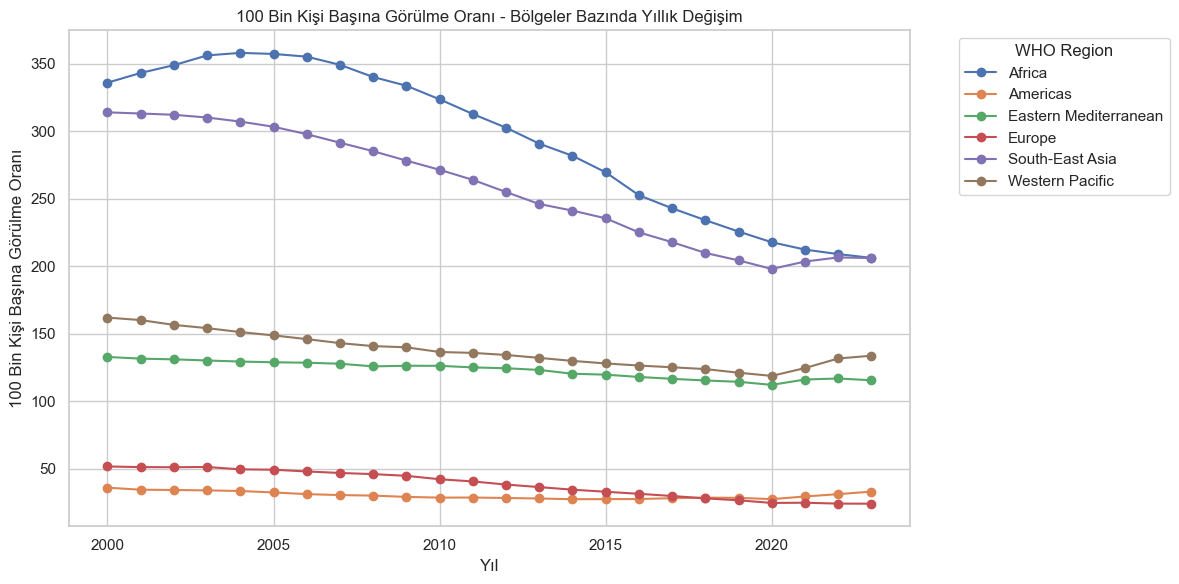

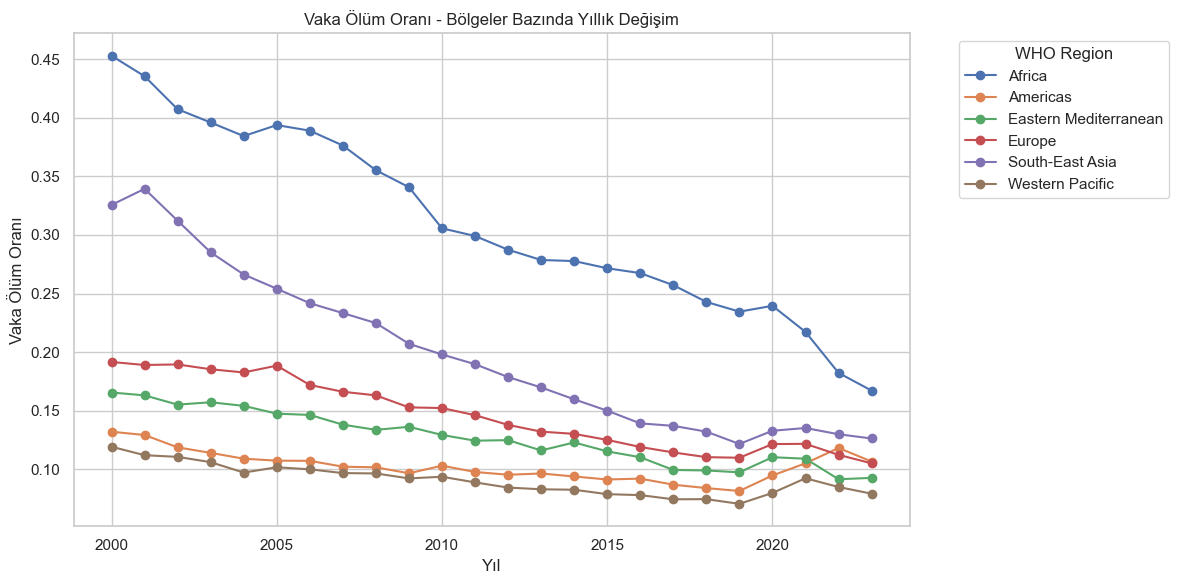

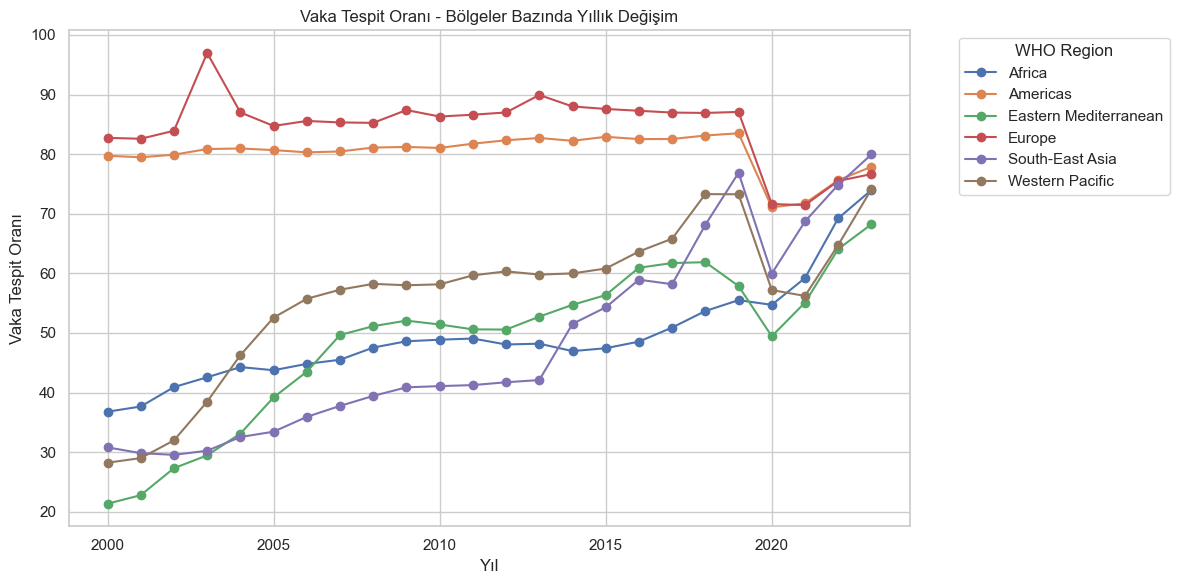

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# VERİYİ OKU
# ============================================

df = pd.read_csv("veri_temiz.csv")

# Sayısal sütunlar
numeric_cols = ["Year","Case_Detection_Rate","Case_Fatality_Ratio","e_inc_100k","e_inc_num","e_pop_num"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================
# AĞIRLIKLI ORTALAMA FONKSİYONU
# ============================================

def weighted_mean(values, weights):
    mask = (~values.isna()) & (~weights.isna())
    values = values[mask]
    weights = weights[mask]

    if weights.sum() == 0:
        return np.nan

    return np.average(values, weights=weights)

# ============================================
# YIL + BÖLGE BAZLI HESAPLAMA
# ============================================

region_year = (
    df
    .groupby(["WHO_region", "Year"])
    .apply(lambda x: pd.Series({

        "Toplam_TB_Vakasi": x["e_inc_num"].sum(),
        "Toplam_Nufus": x["e_pop_num"].sum(),

        "100 Bin Kişi Başına Görülme Oranı":
            weighted_mean(x["e_inc_100k"], x["e_pop_num"]),

        "Vaka Ölüm Oranı":
            weighted_mean(x["Case_Fatality_Ratio"], x["e_inc_num"]),

        "Vaka Tespit Oranı":
            weighted_mean(x["Case_Detection_Rate"], x["e_inc_num"])
    }),
    include_groups=False
    )
    .reset_index()
)

# ============================================
# GRAFİKLER
# ============================================

sns.set(style="whitegrid")

metrics = [
    "100 Bin Kişi Başına Görülme Oranı",
    "Vaka Ölüm Oranı",
    "Vaka Tespit Oranı"
]


regions = region_year["WHO_region"].unique()

for metric in metrics:

    plt.figure(figsize=(12, 6))

    for region in regions:
        df_r = region_year[region_year["WHO_region"] == region]

        plt.plot(
            df_r["Year"],
            df_r[metric],
            marker="o",
            label=region
        )

    plt.title(f"{metric} - Bölgeler Bazında Yıllık Değişim")
    plt.xlabel("Yıl")
    plt.ylabel(metric)
    plt.legend(title="WHO Region", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

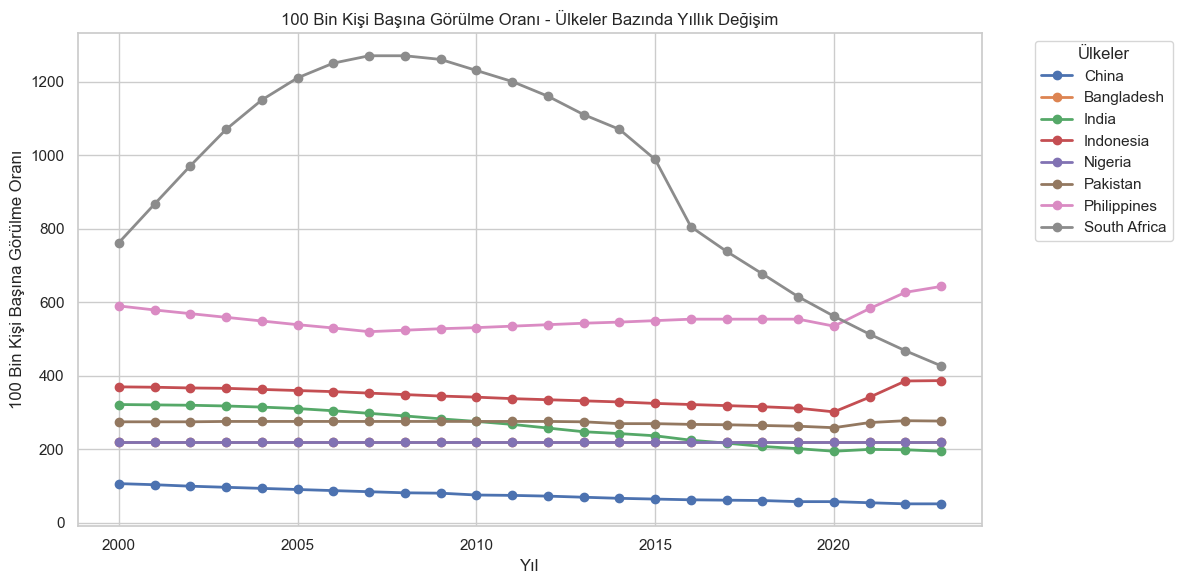

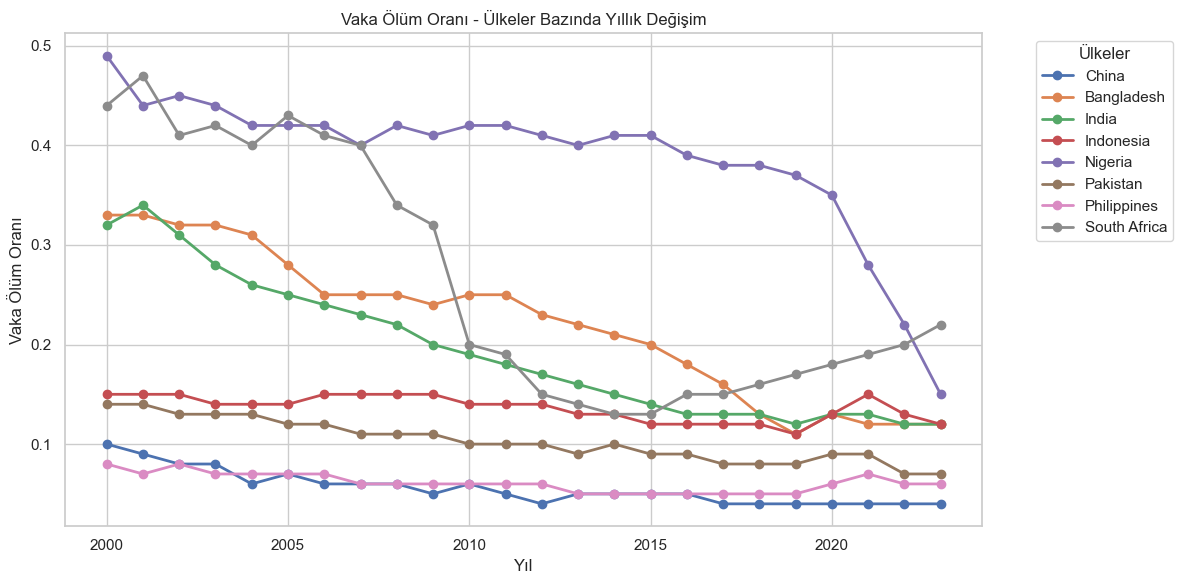

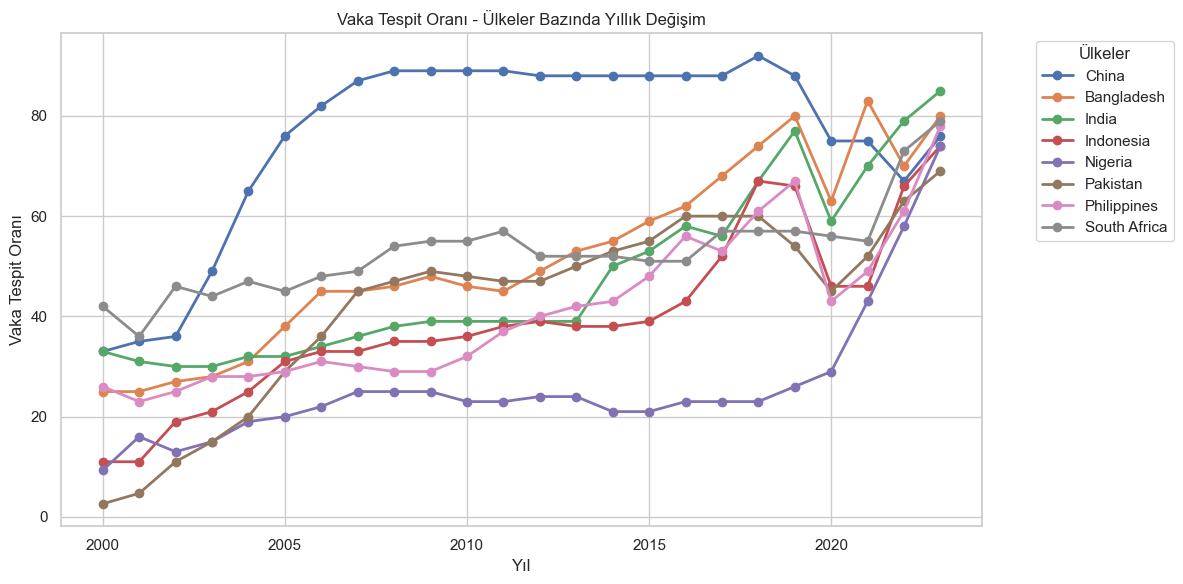

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("veri_temiz.csv")


numeric_cols = ["Year","Case_Detection_Rate","Case_Fatality_Ratio","e_inc_100k","e_inc_num","e_pop_num"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


countries = ["China","Bangladesh","India","Indonesia","Nigeria","Pakistan","Philippines","South Africa"]


df_countries = df[df["Country"].isin(countries)].copy()


sns.set(style="whitegrid")

metrics = [
    "e_inc_100k",
    "Case_Fatality_Ratio",
    "Case_Detection_Rate"
]

metric_labels = {
    "e_inc_100k": "100 Bin Kişi Başına Görülme Oranı",
    "Case_Fatality_Ratio": "Vaka Ölüm Oranı",
    "Case_Detection_Rate": "Vaka Tespit Oranı"
}


for metric in metrics:

    plt.figure(figsize=(12, 6))

    for country in countries:

        df_country = (
            df_countries[df_countries["Country"] == country]
            .sort_values("Year")
        )

        plt.plot(
            df_country["Year"],
            df_country[metric],
            marker="o",
            linewidth=2,
            label=country
        )

    plt.title(f"{metric_labels[metric]} - Ülkeler Bazında Yıllık Değişim")

    plt.xlabel("Yıl")
    plt.ylabel(metric_labels[metric])

    plt.legend(
        title="Ülkeler",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [49]:
# TÜBERKÜLOZ VERİ SETİ ANALİZİ

import pandas as pd
import numpy as np

import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv("veri_temiz.csv")


target = "Case_Fatality_Ratio"

features = [
    "Case_Detection_Rate",
    "e_inc_100k",
    "e_inc_num",
    "e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k"
]

X = df[features]
y = df[target]


X_reg = sm.add_constant(X)

model = sm.OLS(y, X_reg).fit()

print("\nÇoklu Regresyon Sonuçları:")
print(model.summary())



Çoklu Regresyon Sonuçları:
                             OLS Regression Results                            
Dep. Variable:     Case_Fatality_Ratio   R-squared:                       0.470
Model:                             OLS   Adj. R-squared:                  0.470
Method:                  Least Squares   F-statistic:                     1000.
Date:                 Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                         01:13:22   Log-Likelihood:                 4749.8
No. Observations:                 4513   AIC:                            -9490.
Df Residuals:                     4508   BIC:                            -9458.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

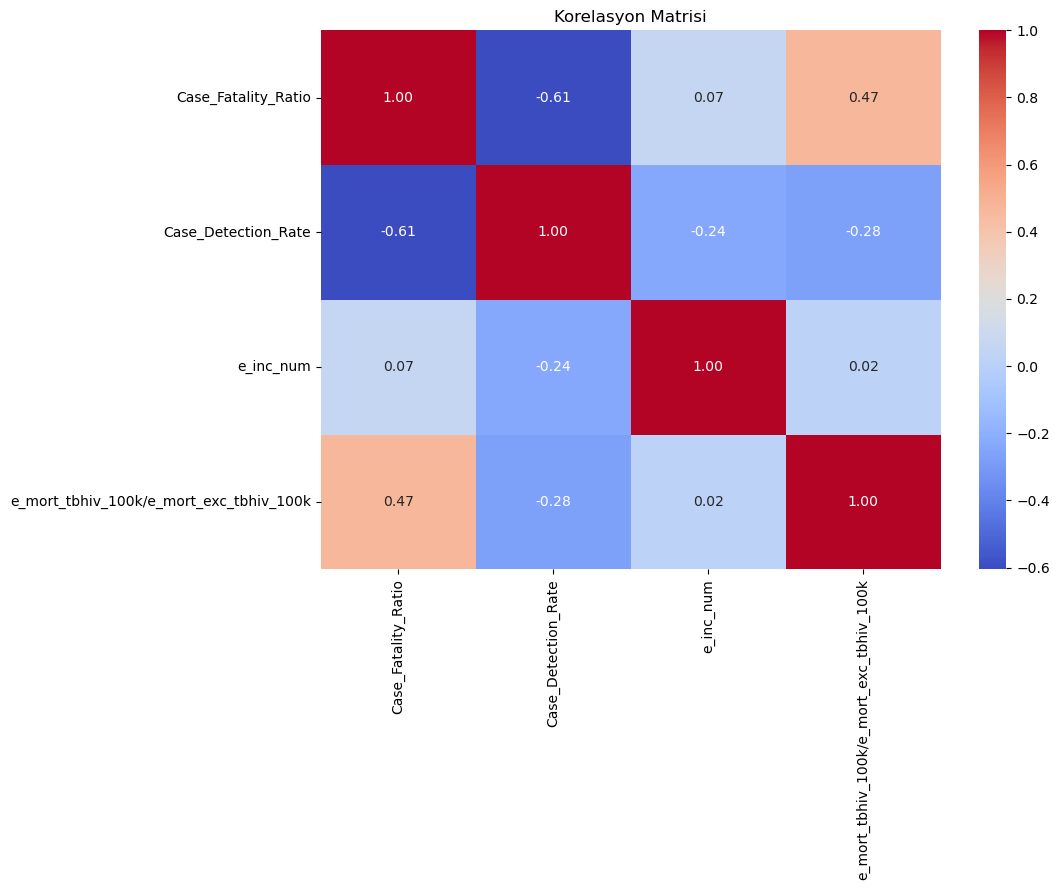


VIF Sonuçları:
                                  Variable        VIF
0                                    const  19.507132
1                      Case_Detection_Rate   1.151234
2                                e_inc_num   1.062258
3  e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k   1.087137

Çoklu Regresyon Sonuçları:
                             OLS Regression Results                            
Dep. Variable:     Case_Fatality_Ratio   R-squared:                       0.470
Model:                             OLS   Adj. R-squared:                  0.470
Method:                  Least Squares   F-statistic:                     1333.
Date:                 Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                         15:22:24   Log-Likelihood:                 4748.9
No. Observations:                 4513   AIC:                            -9490.
Df Residuals:                     4509   BIC:                            -9464.
Df Model:                            3        

In [7]:
# TÜBERKÜLOZ VERİ SETİ ANALİZİ
# ============================================================
# Yapılan analizler:
# 1. Korelasyon matrisi
# 2. VIF (çoklu doğrusal bağlantı)
# 3. Çoklu doğrusal regresyon
# 4. Standartlaştırılmış beta katsayıları
# 6. Regresyon varsayım kontrolleri
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import shapiro


df = pd.read_csv("veri_temiz.csv")

target = "Case_Fatality_Ratio"

features = [
    "Case_Detection_Rate",
    "e_inc_num",
    "e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k"
]

X = df[features]
y = df[target]

# ============================================================
# 1. KORELASYON MATRİSİ
# ============================================================

corr_matrix = df[[target] + features].corr()

# print("\nKorelasyon Matrisi:")
# print(corr_matrix)

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Korelasyon Matrisi")
plt.show()

# ============================================================
# 2. VIF ANALİZİ
# Çoklu doğrusal bağlantı kontrolü
# ============================================================

X_vif = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF Sonuçları:")
print(vif_df)

# Yorum:
# VIF > 5  -> dikkat
# VIF > 10 -> ciddi multicollinearity

# ============================================================
# 3. ÇOKLU DOĞRUSAL REGRESYON
# ============================================================

X_reg = sm.add_constant(X)

model = sm.OLS(y, X_reg).fit()

print("\nÇoklu Regresyon Sonuçları:")
print(model.summary())

# ============================================================
# 4. STANDARTLAŞTIRILMIŞ BETA KATSAYILARI
# ============================================================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(
    y.values.reshape(-1,1)
).flatten()

X_scaled_sm = sm.add_constant(X_scaled)

std_model = sm.OLS(y_scaled, X_scaled_sm).fit()

beta_df = pd.DataFrame({
    "Variable": ["Intercept"] + features,
    "Standardized_Beta": std_model.params
})

print("\nStandartlaştırılmış Beta Katsayıları:")
print(beta_df)

# Mutlak etki büyüklüğüne göre sırala
beta_sorted = beta_df.iloc[1:].copy()

beta_sorted["Abs_Beta"] = beta_sorted["Standardized_Beta"].abs()

beta_sorted = beta_sorted.sort_values(
    by="Abs_Beta",
    ascending=False
)

print("\nEtki Gücüne Göre Değişkenler:")
print(beta_sorted)

# ============================================================
# ARTIK ANALİZİ (Residual Analysis)
# ============================================================

# predictions = model.predict(X_reg)
# residuals = y - predictions

# Histogram
# plt.figure(figsize=(8,5))
# sns.histplot(residuals, kde=True)

# plt.title("Artıkların Dağılımı")
# plt.xlabel("Residual")
# plt.show()

# QQ Plot
# sm.qqplot(residuals, line='45')
# plt.title("QQ Plot")
# plt.show()


In [8]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("veri_temiz.csv")

target = "Case_Fatality_Ratio"
feature = "e_mort_tbhiv_100k/e_mort_exc_tbhiv_100k"

y = df[target]
X = df[[feature]]

X_reg = sm.add_constant(X)

model = sm.OLS(y, X_reg).fit()

print("\nBasit Doğrusal Regresyon Sonuçları:")
print(model.summary())


Basit Doğrusal Regresyon Sonuçları:
                             OLS Regression Results                            
Dep. Variable:     Case_Fatality_Ratio   R-squared:                       0.223
Model:                             OLS   Adj. R-squared:                  0.223
Method:                  Least Squares   F-statistic:                     1293.
Date:                 Tue, 19 May 2026   Prob (F-statistic):          3.52e-249
Time:                         16:51:13   Log-Likelihood:                 3885.0
No. Observations:                 4513   AIC:                            -7766.
Df Residuals:                     4511   BIC:                            -7753.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------